In [8]:
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# columns in data files
# time, sum magnitude, max magnitude
displacements_file = "preciceDisplacementRead.dat"
forces_file = "preciceForceWrite.dat"

displacements_raw = np.loadtxt(displacements_file)
forces_raw = np.loadtxt(forces_file)

In [10]:
displacement_timesteps_raw = displacements_raw[:, 0]

force_timesteps_raw = forces_raw[:, 0]

In [ ]:
# deduplicate timesteps over the iterations
displacement_dict = {}
for i, t in enumerate(displacement_timesteps_raw):
    displacement_dict[t] = (displacements_raw[i, 1], displacements_raw[i, 2])

force_dict = {}
for i, t in enumerate(force_timesteps_raw):
    force_dict[t] = (forces_raw[i, 1], forces_raw[i, 2])

# write data will have initial timestep 0, read data will not
timesteps = np.array(list(force_dict.keys()))
displacements_np = np.array([displacement_dict[t] for t in timesteps])
forces_np = np.array([force_dict[t] for t in timesteps])

In [31]:
displacement_sum_magnitude = displacements_np[:, 0]
displacement_max_magnitude = displacements_np[:, 1]

force_sum_magnitude = forces_np[:, 0]
force_max_magnitude = forces_np[:, 1]

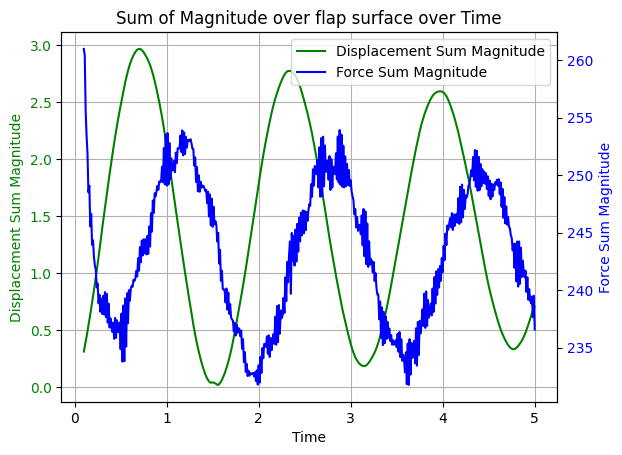

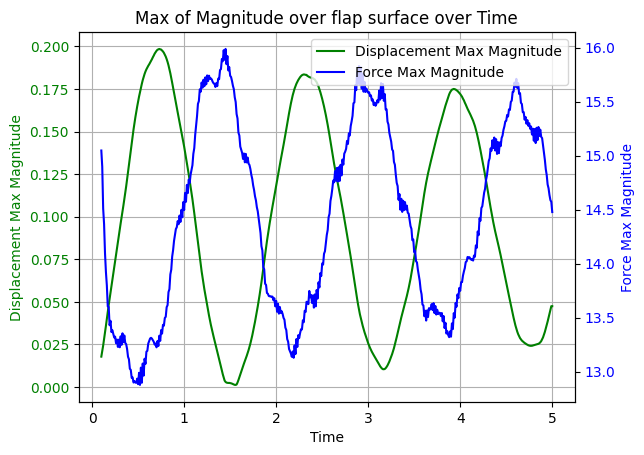

In [44]:
start_time = 0.1

start_index = np.where(timesteps >= start_time)[0][0]

# draw two axes on one plot, one for the displacement, one for the force
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(timesteps[start_index:], displacement_sum_magnitude[start_index:], 'g-', label='Displacement Sum Magnitude')
ax2.plot(timesteps[start_index:], force_sum_magnitude[start_index:], 'b-', label='Force Sum Magnitude')
ax1.set_xlabel('Time')
ax1.set_ylabel('Displacement Sum Magnitude', color='g')
ax1.grid()
ax2.set_ylabel('Force Sum Magnitude', color='b')
ax1.tick_params(axis='y', labelcolor='g')
ax2.tick_params(axis='y', labelcolor='b')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title('Sum of Magnitude over flap surface over Time')
plt.show()


fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(timesteps[start_index:], displacement_max_magnitude[start_index:], 'g-', label='Displacement Max Magnitude')
ax2.plot(timesteps[start_index:], force_max_magnitude[start_index:], 'b-', label='Force Max Magnitude')
ax1.set_xlabel('Time')
ax1.set_ylabel('Displacement Max Magnitude', color='g')
ax1.grid()
ax2.set_ylabel('Force Max Magnitude', color='b')
ax1.tick_params(axis='y', labelcolor='g')
ax2.tick_params(axis='y', labelcolor='b')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title('Max of Magnitude over flap surface over Time')
plt.show()
